# Punto 3 — V1.0 — Mapas de equipos (con Pass Network)

**Proyecto Final V1.0** · Lucas Marinelli · @datafutbol_ar

> **Cambio respecto a V0:** agrego una sección nueva con **Pass Network** de ambos equipos, siguiendo la corrección #1 de Federico Rábanos. El mapa de pases "literal" (V0) se queda igual porque no estaba mal — el Pass Network es el agregado importante.

## Por qué el Pass Network es la viz "correcta"

Federico me lo explicó así: *"el mapa de pases literal está OK, pero la idea era hacer lo del video del Módulo 3 — algo más importante a nivel de análisis de estructura de equipos."*

Tenía razón. Un mapa con flechas muestra **dónde se pasó la pelota**. Un Pass Network muestra **cómo juega el equipo**:

- Quién es el **organizador** (nodo grande con muchas conexiones)
- Qué **dupla / triángulo** se conecta más (líneas gruesas entre 2-3 jugadores)
- Si la circulación es **simétrica o cargada** hacia un lado
- Si juega **corto** (nodos cerca) o **largo** (nodos separados)

### Reglas técnicas que tomé

| Decisión | Por qué |
|---|---|
| Calcular **hasta el primer cambio** | Después la estructura cambia → mezclo datos de "dos equipos distintos" |
| **Mínimo 3 pases** para que la conexión cuente | Filtra conexiones casuales — me quedo solo con las que muestran patrón real |
| Tamaño del nodo proporcional a **n_pases** del jugador | Indicador visual de cuánto participó cada uno en la circulación |
| Grosor de la línea proporcional a **pases entre el par** | El "eje principal" del equipo se ve grueso |
| Etiquetas con el **apellido** | El nombre completo no entra y se monta sobre el siguiente |


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Importo helpers desde la carpeta de la V0 (no duplico código)
V0_PATH = Path('..').resolve() / 'Proyecto_Final_Lucas_Marinelli'
if str(V0_PATH) not in sys.path:
    sys.path.insert(0, str(V0_PATH))

# También agrego la carpeta actual (V1.0) para importar pass_network.py
if str(Path('.').resolve()) not in sys.path:
    sys.path.insert(0, str(Path('.').resolve()))

from helpers import *

# === FIX V1.0: redefinir guardar_fig para que apunte a outputs_v1/ de la carpeta actual ===
# (la version original de helpers.py apunta a outputs/ de V0)
OUTPUTS_V1_DIR = Path('outputs_v1').resolve()
OUTPUTS_V1_DIR.mkdir(exist_ok=True)
def guardar_fig(fig, nombre, dpi=200):
    ruta = OUTPUTS_V1_DIR / (nombre if nombre.endswith('.png') else f'{nombre}.png')
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'[fig V1.0] guardada {ruta.name}')
    return ruta

from pass_network import calcular_pass_network, dibujar_pass_network
import matplotlib.pyplot as plt
from mplsoccer import Pitch

ev = cargar_eventos(MATCH_ARG_SAU, 'arg_sau')
ev = añadir_xy(ev)
print(f'Eventos cargados: {len(ev):,}')
print(f'Equipos: {list(ev["team"].unique())}')


[helpers] aviso: no pude cargar scripts.style (No module named 'scripts.style'). Sigo sin estilo de marca.
[cache] arg_sau: 3329 eventos leidos de eventos_arg_sau.parquet
Eventos cargados: 3,329
Equipos: ['Argentina', 'Saudi Arabia']


---

## § 1 — Pass Network de Argentina


In [2]:
sust_arg = ev[(ev['type'] == 'Substitution') & (ev['team'] == 'Argentina')]
if not sust_arg.empty:
    primer_cambio = sust_arg['minute'].min()
    print(f'Primer cambio de Argentina: minuto {int(primer_cambio)}')
else:
    print('Argentina no hizo cambios')

pos_arg, conex_arg = calcular_pass_network(ev, 'Argentina', min_pases_conexion=3)
print()
print(f'Jugadores en el network: {len(pos_arg)}')
print(f'Conexiones (>= 3 pases): {len(conex_arg)}')
print()
print('Top 5 conexiones más fuertes:')
print(conex_arg.sort_values('n_pases', ascending=False).head(5).to_string(index=False))


Primer cambio de Argentina: minuto 58

Jugadores en el network: 11
Conexiones (>= 3 pases): 33

Top 5 conexiones más fuertes:
                     pasador                receptor  n_pases
     Cristian Gabriel Romero Nicolás Hernán Otamendi       33
      Leandro Daniel Paredes Nicolás Hernán Otamendi       24
     Cristian Gabriel Romero  Leandro Daniel Paredes       23
Nicolás Alejandro Tagliafico Nicolás Hernán Otamendi       22
      Leandro Daniel Paredes  Rodrigo Javier De Paul       22


[fig V1.0] guardada punto3_pass_network_argentina.png


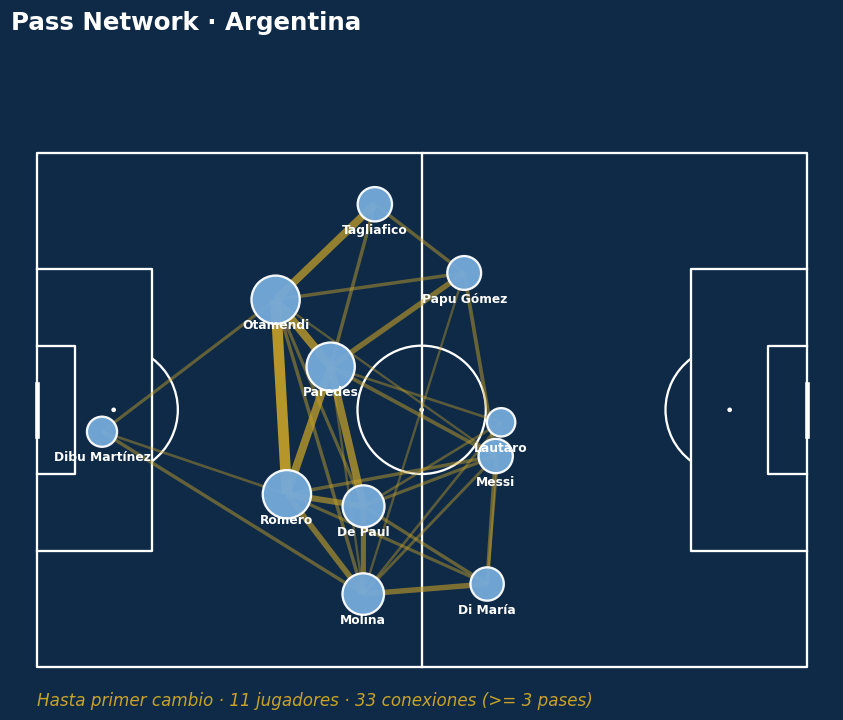

In [3]:
fig, ax = plt.subplots(figsize=(11, 7.5), dpi=110, facecolor=COLORS['bg'])
pitch = Pitch(pitch_type='statsbomb', pitch_color=COLORS['bg'],
              line_color=COLORS['text'], linewidth=1.5, pad_top=15)
pitch.draw(ax=ax)
ax.set_facecolor(COLORS['bg'])

dibujar_pass_network(pos_arg, conex_arg, 'Argentina',
                      ax=ax, pitch=pitch,
                      color_nodo=COLORS['primary'],
                      color_linea=COLORS['accent'],
                      color_texto=COLORS['text'])

ax.set_title('Pass Network · Argentina',
             color=COLORS['text'], fontsize=16, weight='bold',
             loc='left', pad=18)
ax.text(0, 86,
        f'Hasta primer cambio · {len(pos_arg)} jugadores · '
        f'{len(conex_arg)} conexiones (>= 3 pases)',
        color=COLORS['accent'], fontsize=11, style='italic')

watermark(fig, 'Datos: StatsBomb Open Data')
guardar_fig(fig, 'punto3_pass_network_argentina')
plt.show()


---

## § 2 — Pass Network de Arabia Saudita


In [4]:
sust_sau = ev[(ev['type'] == 'Substitution') & (ev['team'] == 'Saudi Arabia')]
if not sust_sau.empty:
    primer_cambio = sust_sau['minute'].min()
    print(f'Primer cambio de Arabia Saudita: minuto {int(primer_cambio)}')
else:
    print('Arabia Saudita no hizo cambios')

pos_sau, conex_sau = calcular_pass_network(ev, 'Saudi Arabia', min_pases_conexion=3)
print()
print(f'Jugadores: {len(pos_sau)}')
print(f'Conexiones: {len(conex_sau)}')
print()
print('Top 5 conexiones más fuertes:')
print(conex_sau.sort_values('n_pases', ascending=False).head(5).to_string(index=False))


Primer cambio de Arabia Saudita: minuto 47

Jugadores: 11
Conexiones: 21

Top 5 conexiones más fuertes:
                       pasador                    receptor  n_pases
Abdulelah Saad Hameed Al-Malki Hassan Mohammed Al-Tambakti        9
                Mohammed Kanoo   Saud Abdullah Abdul Hamid        8
Abdulelah Saad Hameed Al-Malki    Salman Mohammed Al Faraj        7
Abdulelah Saad Hameed Al-Malki              Mohammed Kanoo        6
   Hassan Mohammed Al-Tambakti    Mohammed Khalil Al Owais        5


[fig V1.0] guardada punto3_pass_network_arabia.png


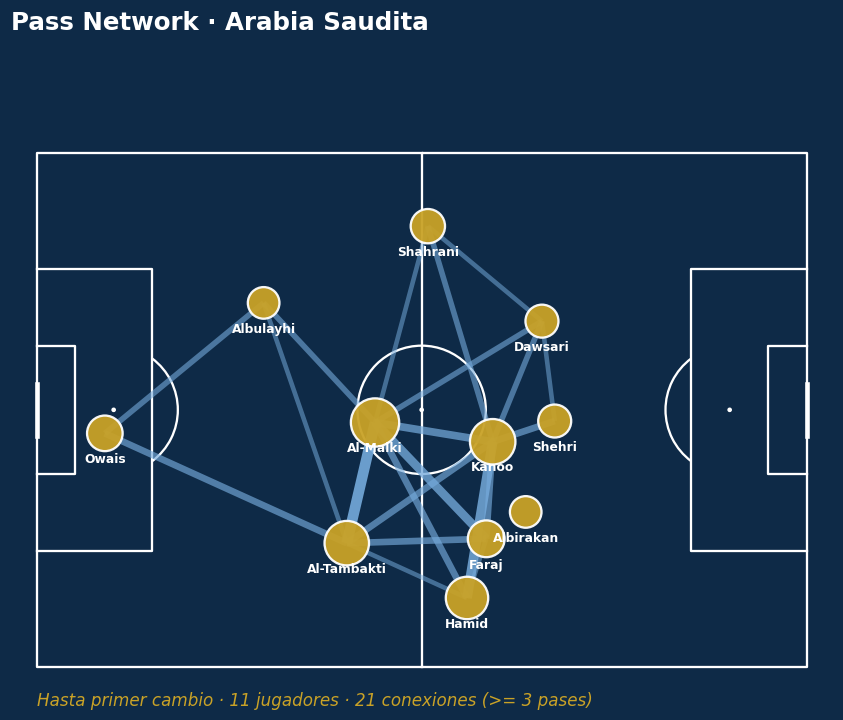

In [5]:
fig, ax = plt.subplots(figsize=(11, 7.5), dpi=110, facecolor=COLORS['bg'])
pitch = Pitch(pitch_type='statsbomb', pitch_color=COLORS['bg'],
              line_color=COLORS['text'], linewidth=1.5, pad_top=15)
pitch.draw(ax=ax)
ax.set_facecolor(COLORS['bg'])

dibujar_pass_network(pos_sau, conex_sau, 'Saudi Arabia',
                      ax=ax, pitch=pitch,
                      color_nodo=COLORS['accent'],
                      color_linea=COLORS['primary'],
                      color_texto=COLORS['text'])

ax.set_title('Pass Network · Arabia Saudita',
             color=COLORS['text'], fontsize=16, weight='bold',
             loc='left', pad=18)
ax.text(0, 86,
        f'Hasta primer cambio · {len(pos_sau)} jugadores · '
        f'{len(conex_sau)} conexiones (>= 3 pases)',
        color=COLORS['accent'], fontsize=11, style='italic')

watermark(fig, 'Datos: StatsBomb Open Data')
guardar_fig(fig, 'punto3_pass_network_arabia')
plt.show()


---

## § 3 — Lectura comparada

| Pregunta | Cómo leo el Pass Network |
|---|---|
| **¿Quién es el organizador?** | El nodo más grande con más líneas saliendo. En Argentina típicamente Romero o De Paul. |
| **¿Por qué lado circuló más el equipo?** | Si los nodos del lateral izquierdo están más conectados entre sí, ahí cargó el juego. |
| **¿Hubo una dupla destacada?** | Línea muy gruesa entre 2 nodos → esos dos jugadores se buscaron mucho. |
| **¿El equipo jugó corto o largo?** | Nodos pegados = juego asociativo. Nodos separados = juego largo y vertical. |
| **¿Hay alguien aislado?** | Nodo sin líneas (o con muy pocas) → jugador que no participó del circuito. |

## Resumen — Punto 3 V1.0 ✅

| Archivo | Descripción |
|---|---|
| `outputs_v1/punto3_pass_network_argentina.png` | Pass Network ARG (titulares hasta primer cambio) |
| `outputs_v1/punto3_pass_network_arabia.png` | Pass Network SAU |
| `pass_network.py` | Módulo reusable para futuros partidos |

### Lo que aprendí

1. **"Mapa de pases" en football analytics = Pass Network.** El mapa literal de flechas se llama Pass Map y es secundario.
2. **El primer cambio define el límite del análisis.** Después la estructura ya no es la misma — cualquier conclusión queda contaminada por la mezcla de dos configuraciones tácticas.
3. **El filtro de "mínimo 3 pases entre par" es importante.** Sin eso, todas las parejas tienen línea y el gráfico se vuelve sopa de spaghetti.
